# BEE 4750 Homework 4: Linear Programming and Capacity Expansion

**Name**: Claire Jacobson

**ID**: cpj35

> **Due Date**
>
> Thursday, 11/06/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to analytically (or graphically) solve a linear
    program.
-   Problem 2 asks you to formulate and solve a resource allocation
    problem using linear programming.
-   Problem 3 asks you to formulate, solve, and analyze a standard
    generating capacity expansion problem.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [34]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/hw4-clairepj`


In [76]:
using JuMP
using HiGHS
using DataFrames
using Plots
using Measures
using CSV
using MarkdownTables
using Statistics

## Problems (Total: 30 Points)

### Problem 1 (Total: 3 Points)

Solve the following linear program **analytically**. Show your work and
justify any reasoning.

$$
\begin{alignedat}{2}
&& \max_{x, y} \quad & 3x + 2y\\
&&\text{subject to:} \quad & x + 4y \leq 16\\
& && x - 2y \leq -1\\
& && 0 \leq x \leq 4\\
& && 1 \leq y \leq 4.
\end{alignedat}
$$

Points of intersection: x=4 and y=4 w/ x+4y = 16, x=4 and y=1 w/ x-2y =-1, max can only occur at intersections, evaluate each intersection. Points (4,3), (0,4), (4,2.5), and (1,1), respectively. These points all lie on the corners of the cross-section area which means they are within the constraints of the system. Next I will evaluate the solution to 3x+2y to find the maximum. The values are (3*4)+(2*3) = 18, (3*0)+(2*4)=8, (3*4)+(2*2.5)=17, and (3*1)+(2*1)=5, respectively. Therefore, the maximum of 3x+2y occurs at the point (4,3).

### Problem 2 (12 points)

A farmer has access to a pesticide which can be used on corn, soybeans,
and wheat fields, and costs \$70/kg-yr to apply. The crop yields the
farmer can obtain following crop yields by applying varying rates of
pesticides to the field are shown in
<a href="#tbl-yields" class="quarto-xref">Table 1</a>.

| Application Rate (kg/ha) | Soybean (kg/ha) | Wheat (kg/ha) | Corn (kg/ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      2900       |     3500      |     5900     |
|            1             |      3800       |     4100      |     6700     |
|            2             |      4400       |     4200      |     7900     |

Table 1: Crop yields from applying varying pesticide rates for Problem
1.

The costs of production, *excluding pesticides*, for each crop, and
selling prices, are shown in
<a href="#tbl-costs" class="quarto-xref">Table 2</a>.

|   Crop   | Production Cost (\$/ha-yr) | Selling Price (\$/kg) |
|:--------:|:--------------------------:|:---------------------:|
| Soybeans |            350             |         0.36          |
|  Wheat   |            280             |         0.27          |
|   Corn   |            390             |         0.22          |

Table 2: Costs of crop production, excluding pesticides, and selling
prices for each crop.

Recently, environmental authorities have declared that farms cannot have
an *average* application rate on soybeans, wheat, and corn which exceeds
0.8, 0.7, and 0.6 kg/ha, respectively. The farmer has asked you for
advice on how they should plant crops and apply pesticides to maximize
profits over 130 total ha while remaining in regulatory compliance if
demand for each crop (which is the maximum the market would buy) this
year is 250,000 kg?

#### Problem 2.1

Formulate a linear program for this resource allocation problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations). **Tip:
Make sure that all of your constraints are linear**.

#### Problem 2.2

How many ha should the farmer dedicate to each crop and with what
pesticide application rate(s)? How much profit will the farmer expect to
make?

| Application Rate (kg/ha) |  Soybean (ha) |  Wheat (ha) |  Corn (ha) |
|:------------------------:|:-------------:|:-----------:|:----------:|
|            0             |    13.81      |    55.25    |    0.0     |
|            1             |     6.74      |    15.73    |     0.0    |
|            2             |     26.92     |    0.0      |    11.53   |

Profit: $116,741.17

#### Problem 2.3

The farmer has an opportunity to buy an extra 10 ha of land. How much
extra profit would this land be worth to the farmer? Discuss why this
value makes sense and under what conditions you would recommend the
farmer should make the purchase.

The new profit would be $124,035.17 meaning the addition of 10 acres
of land would lead to a little over $7,000 increase in profit. This
addition would only be logical if this benefit outweighs the cost of the
purchase of the land itself. Further, the farmer should consider if they
have the capacity to work on 10 more ha of land (though in theory this is 
already accounted for in the cost of cultivating the crops).

In [36]:
#2.1

#table of all values for each crop

data = DataFrame(
    crop = ["Soy", "Wheat", "Corn"],
    yield_0 = [2900, 3500, 5900],      
    yield_1 = [3800, 4100, 6700],      
    yield_2 = [4400, 4200, 7900], 
    cost_prod = [350, 280, 390],       
    profit = [0.36, 0.27, 0.22],      
    max_app = [0.8, 0.7, 0.6]        
)

#constants/limits
pesticide_cost =70
ha_max =140
dmd = 250_000
rates = 0:2

rows = nrow(data)

crop_model = Model(HiGHS.Optimizer) # initialize model object
@variable(crop_model, ha[1:rows,0:2] >= 0) # non-negativity constraints

@expression(crop_model, revenue,
    sum(data.profit[i] * data[!, Symbol("yield_$(r)")][i] * ha[i, r] for i in 1:rows, r in rates)
)
@expression(crop_model, prod_cost,
    sum(data.cost_prod[i] * ha[i, r] for i in 1:rows, r in rates)
)
@expression(crop_model, pesticide_spent,
    sum(pesticide_cost * r * ha[i, r] for i in 1:rows, r in rates)
)

@objective(crop_model, Max, revenue - prod_cost - pesticide_spent)

@constraint(crop_model, sum(ha[i, r] for i in 1:rows, r in rates) <= ha_max)
@constraint(crop_model, [i in 1:rows],sum(data[!, Symbol("yield_$(r)")][i] * ha[i, r] for r in rates) <= dmd)
@constraint(crop_model, [i in 1:rows], sum(r * ha[i, r] for r in rates) <= data.max_app[i] * sum(ha[i, r] for r in rates))

optimize!(crop_model)

print(crop_model) # this outputs a nicely formatted summary of the model so you can check your specification


Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 7 rows; 9 cols; 27 nonzeros
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.8170298458e+02 Ph1: 7(28.3601); Du: 9(181.703) 0s
          7     1.2403516702e+05 Pr: 0(0) 0s
Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.2403516702e+05
P-D objective error :  1.1732040935e-16
HiGHS run time      :          0.02


In [ ]:
#2.2 
@show("crops and application values")
@show value.(ha);

@show("net profit from crops:")
@show objective_value(crop_model);

"crops and application values" = "crops and application values"
value.(ha) = 2-dimensional DenseAxisArray{Float64,2,...} with index sets:
    Dimension 1, Base.OneTo(3)
    Dimension 2, 0:2
And data, a 3×3 Matrix{Float64}:
 13.81215469613259   55.2486187845304     0.0
  9.743306417339566  22.734381640458984   0.0
 26.923076923076923   0.0                11.538461538461522
"net profit from crops:" = "net profit from crops:"
objective_value(crop_model) = 124035.16702082446


### Problem 3 (15 points)

For this problem, we will use hourly load (demand) data from 2013 in New
York’s Zone C (which includes Ithaca). The load data is loaded and
plotted below in <a href="#fig-demand" class="quarto-xref">Figure 1</a>.

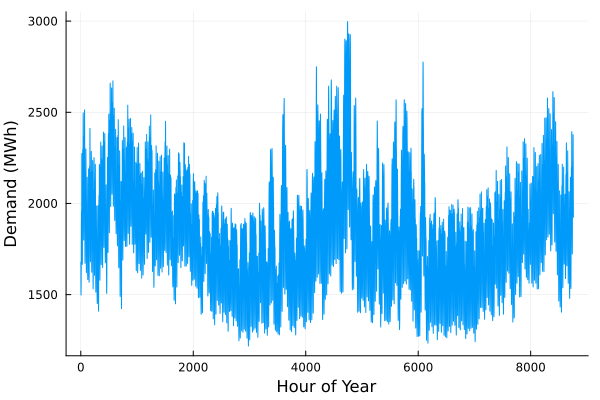

In [38]:
# load the data, pull Zone C, and reformat the DataFrame
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, :"Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand[:, :Hour] = 1:nrow(demand)

# plot demand
plot(demand.Hour, demand.Demand, xlabel="Hour of Year", ylabel="Demand (MWh)", label=:false)

Next, we load the generator data, shown in
<a href="#tbl-generators" class="quarto-xref">Table 3</a>. This data
includes fixed costs (\$/MW installed), variable costs (\$/MWh
generated), and CO<sub>2</sub> emissions intensity (tCO<sub>2</sub>/MWh
generated).

In [39]:
gens = DataFrame(CSV.File("data/generators.csv"))

Row,Plant,FixedCost,VarCost,Emissions
,String15,Int64,Int64,Float64
1,Geothermal,450000,0,0.0
2,Coal,220000,24,1.0
3,NG CCGT,82000,30,0.43
4,NG CT,65000,40,0.55
5,Wind,91000,0,0.0
6,Solar,70000,0,0.0


Finally, we load the hourly solar and wind capacity factors, which are
plotted in <a href="#fig-cf" class="quarto-xref">Figure 2</a>. These
tell us the fraction of installed capacity which is expected to be
available in a given hour for generation (typically based on the average
meteorology).

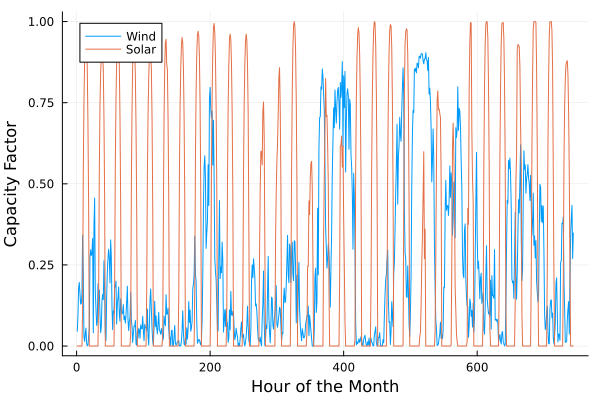

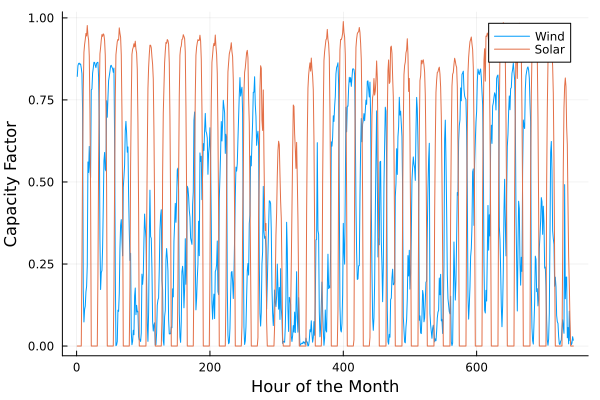

In [40]:
# load capacify factors into a DataFrame
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))

# plot January capacity factors
p1 = plot(cap_factor.Wind[1:(24*31)], label="Wind")
plot!(cap_factor.Solar[1:(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

p2 = plot(cap_factor.Wind[4344:4344+(24*31)], label="Wind")
plot!(cap_factor.Solar[4344:4344+(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

display(p1)
display(p2)

You have been asked to develop a generating capacity expansion plan for
the utility in Riley County, NY, which currently has no existing
electrical generation infrastructure. The utility can build any of the
following plant types: geothermal, coal, natural gas combined cycle gas
turbine (CCGT), natural gas combustion turbine (CT), solar, and wind.
The NY state legislature is planning to enact an annual CO<sub>2</sub>
limit, which for the utility would limit the emissions in its footprint
to 1.5 MtCO<sub>2</sub>/yr.

While coal, CCGT, and CT plants can generate at their full installed
capacity, geothermal plants operate at maximum 85% capacity, and solar
and wind available capacities vary by the hour depend on the expected
meteorology. The utility will also penalize any non-served demand at a
rate of \$10,000/MWh.

#### Problem 3.1

Formulate a linear program for this capacity expansion problem,
including clear definitions of decision variable(s) (including units),
objective function(s), and constraint(s) (make sure to explain functions
and constraints with any needed derivations and explanations).

#### Problem 3.2

How much should the utility build of each type of generating plant? What
will the total cost be? How much energy will be non-served?

#### Problem 3.3

What fraction of annual generation does each plant type produce? How
does this compare to the breakdown of built capacity that you found in
Problem 3.2? Do these results make sense given the demand and generator
data?

#### Problem 3.4

Make a plot of the electricity price in each hour. Discuss any trends
that you see.

#### Problem 3.5

What is the shadow price of CO<sub>2</sub>? What is the value to the
utility be of allowing it to emit an additional 1000 tCO<sub>2</sub>/yr?

> **Significant Digits**
>
> Use `round(x; digits=n)` to report values to the appropriate
> precision! If your number is on a different order of magnitude and you
> want to round to a certain number of significant digits, you can use
> `round(x; sigdigits=n)`.

> **Getting Variable Output Values**
>
> `value.(x)` will report the values of a `JuMP` variable `x`, but it
> will return a special container which holds other information about
> `x` that is useful for `JuMP`. This means that you can’t use this
> output directly for further calculations. To just extract the values,
> use `value.(x).data`.

> **Suppressing Model Command Output**
>
> The output of specifying model components (variable or constraints)
> can be quite large for this problem because of the number of time
> periods. If you end a cell with an `@variable` or `@constraint`
> command, I *highly* recommend suppressing output by adding a
> semi-colon after the last command, or you might find that your
> notebook crashes.

In [41]:
names(gens)

4-element Vector{String}:
 "Plant"
 "FixedCost"
 "VarCost"
 "Emissions"

In [69]:
println("Column names in demand DataFrame:")
println(names(demand))
println("\nFirst few rows of demand:")
println(first(demand, 5))
println("\nData types in demand:")
println(eltype.(eachcol(demand)))

techs = String.(gens[!, :Plant])
hours = 1:8760

FixedCost = Dict{String, Float64}(zip(techs, gens[!, :FixedCost]))
VarCost = Dict{String, Float64}(zip(techs, gens[!, :VarCost]))
E = Dict{String, Float64}(zip(techs, gens[!, :Emissions]))

demand_vec = Float64[]
for col in names(demand)
    if eltype(demand[!, col]) <: Number
        demand_vec = Float64.(demand[!, col])
        println("\nUsing column '$col' for demand")
        break
    end
end

if isempty(demand_vec)
    error("Could not find numeric demand column!")
end

avail_dict = Dict{Tuple{String, Int64}, Float64}()
for i in techs
    for t in hours
        if i == "Wind"
            avail_dict[i, t] = cap_factor[t, :Wind]
        elseif i == "Solar"
            avail_dict[i, t] = cap_factor[t, :Solar]
        elseif i == "Geothermal"
            avail_dict[i, t] = 0.85
        else
            avail_dict[i, t] = 1.0
        end
    end
end

capacity_model = Model(HiGHS.Optimizer)

@variable(capacity_model, C[i in techs] >= 0)
@variable(capacity_model, g[i in techs, t in hours] >= 0)
@variable(capacity_model, u[t in hours] >= 0)

@constraint(capacity_model, [t in hours], sum(g[i,t] for i in techs) + u[t] == demand_vec[t])
@constraint(capacity_model, [i in techs, t in hours], g[i,t] <= C[i] * avail_dict[i,t])
@constraint(capacity_model, sum(E[i] * g[i,t] for i in techs, t in hours) <= 1.5e6)

@objective(capacity_model, Min, sum(FixedCost[i]*C[i] for i in techs)
            + sum(VarCost[i]*g[i,t] for i in techs, t in hours)
            + sum(10000*u[t] for t in hours))

@constraint(capacity_model, demand_constraint[t in hours], 
    sum(g[i,t] for i in techs) + u[t] == demand_vec[t])

Column names in demand DataFrame:
["Date", "Demand", "Hour"]

First few rows of demand:
5×3 DataFrame
 Row │ Date         Demand   Hour  
     │ String15     Float64  Int64 
─────┼─────────────────────────────
   1 │ 1/1/13 0:00   1678.3      1
   2 │ 1/1/13 1:00   1596.7      2
   3 │ 1/1/13 2:00   1522.8      3
   4 │ 1/1/13 3:00   1497.7      4
   5 │ 1/1/13 4:00   1507.8      5

Data types in demand:
DataType[String15, Float64, Int64]

Using column 'Demand' for demand


1-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape},1,...} with index sets:
    Dimension 1, 1:8760
And data, a 8760-element Vector{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarAffineFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 demand_constraint[1] : g[Geothermal,1] + g[Coal,1] + g[NG CCGT,1] + g[NG CT,1] + g[Wind,1] + g[Solar,1] + u[1] = 1678.3
 demand_constraint[2] : g[Geothermal,2] + g[Coal,2] + g[NG CCGT,2] + g[NG CT,2] + g[Wind,2] + g[Solar,2] + u[2] = 1596.7
 demand_constraint[3] : g[Geothermal,3] + g[Coal,3] + g[NG CCGT,3] + g[NG CT,3] + g[Wind,3] + g[Solar,3] + u[3] = 1522.8
 demand_constraint[4] : g[Geothermal,4] + g[Coal,4] + g[NG CCGT,4] + g[NG CT,4] + g[Wind,4] + g[Solar,4] + u[4] = 1497.7
 demand_constraint[5] : g[Geothermal,5] + g[Coal,5] + g[NG CCGT,5] + g[NG CT,5] + g[Wind,5] + g[Solar,5

In [70]:
#3.2
optimize!(capacity_model)

# Check if the model solved successfully
if termination_status(capacity_model) == MOI.OPTIMAL
    println("Optimal solution found!\n")
    
    # Extract results
    println("="^60)
    println("CAPACITY EXPANSION RESULTS")
    println("="^60)
    
    # How much should be built of each plant type?
    println("\nInstalled Capacity by Plant Type (MW):")
    println("-"^40)
    for i in techs
        capacity = value(C[i])
        println("  $i: $(round(capacity, digits=2)) MW")
    end
    
    # Total cost
    total_cost = objective_value(capacity_model)
    println("\nTotal Cost: \$$(round(total_cost, digits=2))")
    
    # Break down the cost components
    fixed_cost_total = sum(FixedCost[i] * value(C[i]) for i in techs)
    variable_cost_total = sum(VarCost[i] * value(g[i,t]) for i in techs, t in hours)
    unserved_cost_total = sum(10000 * value(u[t]) for t in hours)
    
    println("\nCost Breakdown:")
    println("-"^40)
    println("  Fixed Costs: \$$(round(fixed_cost_total, digits=2))")
    println("  Variable Costs: \$$(round(variable_cost_total, digits=2))")
    println("  Unserved Energy Penalty: \$$(round(unserved_cost_total, digits=2))")
    
    # How much energy will be non-served?
    total_unserved = sum(value(u[t]) for t in hours)
    total_demand = sum(demand_vec[t] for t in hours)
    unserved_percentage = (total_unserved / total_demand) * 100
    
    println("\nUnserved Energy:")
    println("-"^40)
    println("  Total Unserved: $(round(total_unserved, digits=2)) MWh")
    println("  Percentage of Demand: $(round(unserved_percentage, digits=4))%")
    
    # Check emissions constraint
    total_emissions = sum(E[i] * value(g[i,t]) for i in techs, t in hours)
    println("\nEmissions:")
    println("-"^40)
    println("  Total Emissions: $(round(total_emissions, digits=2)) MtCO₂")
    println("  Emissions Limit: 1.5e6 MtCO₂")
    println("  Constraint Satisfied: $(total_emissions <= 1.5e6)")
    
else
    println("Model did not solve to optimality")
    println("Termination status: $(termination_status(capacity_model))")
    println("Primal status: $(primal_status(capacity_model))")
end

Running HiGHS 1.11.0 (git hash: 364c83a51e): Copyright (c) 2025 HiGHS under MIT licence terms
LP   has 70081 rows; 61326 cols; 249576 nonzeros
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 2e+06]
Presolving model
65617 rows, 56862 cols, 236184 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.01s (limit = 1000.00s)
56857 rows, 56862 cols, 179328 nonzeros  0s
Presolve : Reductions: rows 56857(-13224); columns 56862(-4464); elements 179328(-70248)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(5.18855e+06) 1s
      20049     4.3434255541e+08 Pr: 7292(885090); Du: 0(1.88022e-07) 6s
      24682     6.6224376269e+08 Pr: 4709(823380); Du: 0(1.0619e-07) 11s
      28822     7.5673351748e+08 Pr: 10387(4.7314e+06);

In [72]:
# Calculate annual generation by plant type
println("="^60)
println("ANNUAL GENERATION ANALYSIS")
println("="^60)

# Total generation by each plant type
generation_by_plant = Dict{String, Float64}()
total_generation = 0.0

for i in techs
    gen = sum(value(g[i,t]) for t in hours)
    generation_by_plant[i] = gen
    total_generation += gen
end

# Calculate generation fractions
println("\nAnnual Generation by Plant Type:")
println("-"^60)
println("Plant Type        Generation (MWh)      Fraction of Total")
println("-"^60)
for i in techs
    gen = generation_by_plant[i]
    fraction = gen / total_generation
    println("$(rpad(i, 15)) $(rpad(round(gen, digits=0), 20)) $(round(fraction*100, digits=2))%")
end
println("-"^60)
println("Total:            $(round(total_generation, digits=0)) MWh")

# Compare to capacity fractions
println("\n" * "="^60)
println("COMPARISON: GENERATION vs CAPACITY")
println("="^60)
println("Plant Type        Capacity (MW)  Cap %    Generation %   Difference")
println("-"^60)

total_capacity = sum(value(C[i]) for i in techs)

for i in techs
    cap = value(C[i])
    cap_fraction = cap / total_capacity
    gen_fraction = generation_by_plant[i] / total_generation
    diff = gen_fraction - cap_fraction
    
    println("$(rpad(i, 15)) $(rpad(round(cap, digits=0), 13)) " *
            "$(rpad(round(cap_fraction*100, digits=2), 8)) " *
            "$(rpad(round(gen_fraction*100, digits=2), 14)) " *
            "$(round(diff*100, digits=2))%")
end

# Calculate capacity factors for each plant
println("\n" * "="^60)
println("CAPACITY FACTORS (Actual Generation / Potential Generation)")
println("="^60)

for i in techs
    cap = value(C[i])
    if cap > 0
        # Calculate potential generation given availability
        potential_gen = sum(cap * avail_dict[i,t] for t in hours)
        actual_gen = generation_by_plant[i]
        cf = actual_gen / potential_gen
        
        println("$(rpad(i, 15)) CF = $(round(cf*100, digits=2))%")
    end
end

# Analysis and interpretation
println("\n" * "="^60)
println("INTERPRETATION")
println("="^60)
println("\nKey Observations:")

# Check if baseload plants generate more than their capacity share
for i in ["Coal", "Geothermal", "NG CCGT"]
    if i in techs
        cap_frac = value(C[i]) / total_capacity
        gen_frac = generation_by_plant[i] / total_generation
        if gen_frac > cap_frac + 0.05
            println("• $i generates MORE than its capacity share (baseload behavior)")
        end
    end
end

# Check if peaker plants generate less than their capacity share
for i in ["NG CT"]
    if i in techs
        cap_frac = value(C[i]) / total_capacity
        gen_frac = generation_by_plant[i] / total_generation
        if gen_frac < cap_frac - 0.05
            println("• $i generates LESS than its capacity share (peaking behavior)")
        end
    end
end

# Check renewable patterns
for i in ["Solar", "Wind"]
    if i in techs && value(C[i]) > 0
        cap_frac = value(C[i]) / total_capacity
        gen_frac = generation_by_plant[i] / total_generation
        println("• $i: capacity=$(round(cap_frac*100, digits=1))%, " *
                "generation=$(round(gen_frac*100, digits=1))% " *
                "(limited by availability)")
    end
end

println("\nThese results make sense because:")
println("• Baseload plants (low variable cost) run whenever available")
println("• Peaker plants (high variable cost) only run during high-demand periods")
println("• Renewables are limited by weather/time-of-day availability")
println("• The model balances capital costs vs operating costs optimally")

ANNUAL GENERATION ANALYSIS

Annual Generation by Plant Type:
------------------------------------------------------------
Plant Type        Generation (MWh)      Fraction of Total
------------------------------------------------------------
Geothermal      1.096995e6           6.7%
Coal            0.0                  0.0%
NG CCGT         3.322767e6           20.3%
NG CT           129473.0             0.79%
Wind            6.451744e6           39.42%
Solar           5.366594e6           32.79%
------------------------------------------------------------
Total:            1.6367574e7 MWh

COMPARISON: GENERATION vs CAPACITY
Plant Type        Capacity (MW)  Cap %    Generation %   Difference
------------------------------------------------------------
Geothermal      286.0         3.99     6.7            2.71%
Coal            0.0           0.0      0.0            0.0%
NG CCGT         1509.0        21.11    20.3           -0.81%
NG CT           703.0         9.83     0.79           -9.04%


ELECTRICITY PRICE ANALYSIS

Price Statistics:
----------------------------------------
  Mean Price: $-0.0/MWh
  Median Price: $-0.0/MWh
  Min Price: $-0.0/MWh
  Max Price: $-0.0/MWh
  Std Dev: $0.0/MWh
  Hours at $10,000/MWh (unserved): 0


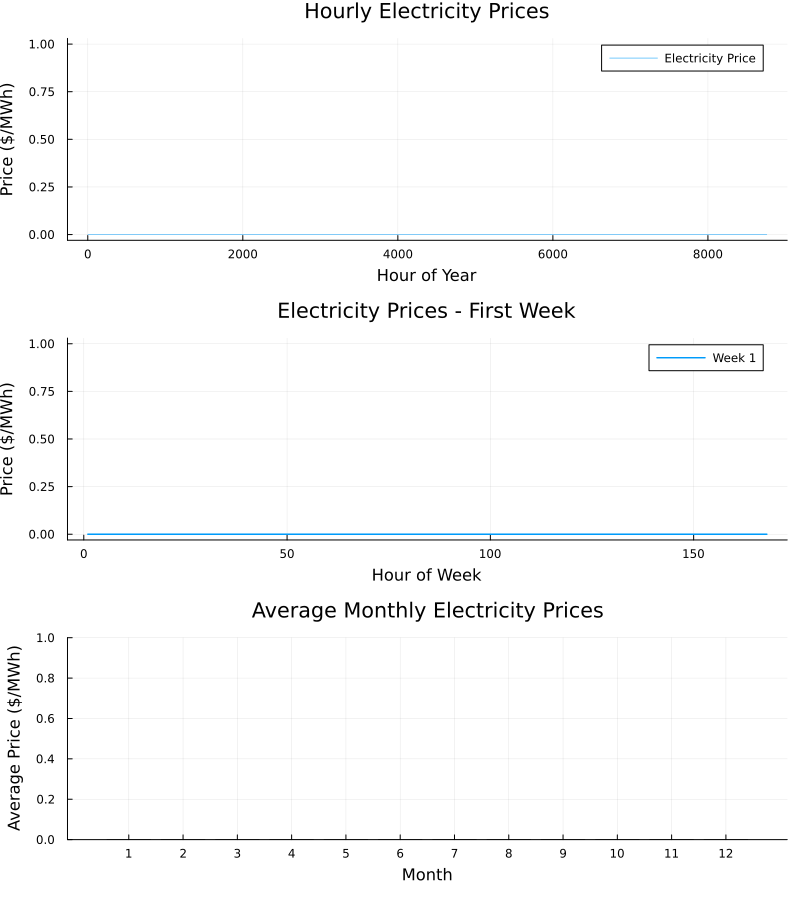

In [78]:
prices = [dual(capacity_model[:demand_constraint][t]) for t in hours]

# Note: If you named your constraint differently, adjust the name above
# The constraint is: sum(g[i,t] for i in techs) + u[t] == demand_vec[t]

println("="^60)
println("ELECTRICITY PRICE ANALYSIS")
println("="^60)

# Summary statistics
println("\nPrice Statistics:")
println("-"^40)
println("  Mean Price: \$$(round(mean(prices), digits=2))/MWh")
println("  Median Price: \$$(round(median(prices), digits=2))/MWh")
println("  Min Price: \$$(round(minimum(prices), digits=2))/MWh")
println("  Max Price: \$$(round(maximum(prices), digits=2))/MWh")
println("  Std Dev: \$$(round(std(prices), digits=2))/MWh")

# Count hours at maximum penalty price
high_price_hours = count(p -> p >= 9999, prices)
println("  Hours at \$10,000/MWh (unserved): $high_price_hours")

# Plot hourly prices for the entire year
p1 = plot(1:8760, prices, 
    label="Electricity Price",
    xlabel="Hour of Year",
    ylabel="Price (\$/MWh)",
    title="Hourly Electricity Prices",
    linewidth=0.5,
    legend=:topright)

# Plot prices for first week (168 hours) to see daily patterns
p2 = plot(1:168, prices[1:168],
    label="Week 1",
    xlabel="Hour of Week",
    ylabel="Price (\$/MWh)",
    title="Electricity Prices - First Week",
    linewidth=1.5,
    legend=:topright)

# Plot monthly average prices
monthly_prices = []
for month in 1:12
    # Approximate hours per month (365/12 ≈ 30.4 days)
    start_hour = Int(round((month-1) * 730)) + 1
    end_hour = min(Int(round(month * 730)), 8760)
    avg_price = mean(prices[start_hour:end_hour])
    push!(monthly_prices, avg_price)
end

p3 = bar(1:12, monthly_prices,
    xlabel="Month",
    ylabel="Average Price (\$/MWh)",
    title="Average Monthly Electricity Prices",
    legend=false,
    xticks=1:12)

# Combine plots
plot(p1, p2, p3, layout=(3,1), size=(800, 900))

## References

List any external references consulted, including classmates.